# Python e API

### O que é uma API?

- É um conjunto de códigos para usar um serviço/site/aplicativo específico. Cada site/ferramenta tem sua própria API. É importante que você saiba ler as APIs que precisar para saber usar

- Um dos padrões mais comuns em API é pegar informações em formato json, uma espécie de dicionário que precisa ser tratada no Python para podermos analisar

- As possibilidades de API são infinitas, vamos fazer 2 exemplos aqui: Cotação de Moedas e Envio de SMS.

- Sites como Google, Youtube, Facebook, Twitter, ArcGis e praticamente qualquer ferramenta/site grande tem uma API.

### O que precisamos:

- Quase sempre você precisa de uma conta para consumir uma API. Algumas APIs são abertas, como a https://docs.awesomeapi.com.br/api-de-moedas , mas em muitos casos (como veremos no caso do SMS) vamos precisar ter uma conta ativa para consumir a API

- A Documentação da API (ou exemplos da internet) é a chave para conseguir usar uma API 

#### Pegar a Cotação Atual de Todas as Moedas 

In [2]:
import json
import requests
r=requests.get("https://economia.awesomeapi.com.br/last/USD-BRL,EUR-BRL,BTC-BRL")
r_dicionario=r.json()
print(r_dicionario)

{'USDBRL': {'code': 'USD', 'codein': 'BRL', 'name': 'Dólar Americano/Real Brasileiro', 'high': '5.1951', 'low': '5.1319', 'varBid': '-0.0549', 'pctChange': '-1.057216', 'bid': '5.138', 'ask': '5.1395', 'timestamp': '1787347191', 'create_date': '2026-08-21 18:19:51'}, 'EURBRL': {'code': 'EUR', 'codein': 'BRL', 'name': 'Euro/Real Brasileiro', 'high': '6.0835', 'low': '5.9968', 'varBid': '-0.0692', 'pctChange': '-1.140036', 'bid': '6.0008', 'ask': '6.0028', 'timestamp': '1787347196', 'create_date': '2026-08-21 18:19:56'}, 'BTCBRL': {'code': 'BTC', 'codein': 'BRL', 'name': 'Bitcoin/Real Brasileiro', 'high': '407223', 'low': '395426', 'varBid': '-4979', 'pctChange': '-1.234', 'bid': '398499', 'ask': '398500', 'timestamp': '1787447358', 'create_date': '2026-08-22 22:09:18'}}


#### Qual foi a última cotação do Dólar, do Euro e do BitCoin? (Sua resposta vai dar diferente do gabarito, porque estamos rodando o código em momentos diferentes, mas o seu código deve ser o mesmo/parecido)

In [3]:
print(f"Euro: {r_dicionario['EURBRL']['bid']}")
print(f"Real: {r_dicionario['BTCBRL']['bid']}")
print(f"Dolar: {r_dicionario['USDBRL']['bid']}")

Euro: 6.0008
Real: 398499
Dolar: 5.138


In [12]:
#Ultimos 15 dias dolar
r2=requests.get("https://economia.awesomeapi.com.br/json/daily/USD-BRL/15")
r2_compila=r2.json()
todos=([float(c['bid'])for c in r2_compila])
print(todos)

[5.138, 5.1929, 5.1788, 5.2133, 5.2042, 5.21917, 5.2225, 5.1795, 5.1904, 5.1573, 5.1066, 5.0808, 5.10989, 5.1216, 5.1237]


#### Pegar a cotação dos últimos 30 dias do dólar (Sua resposta vai dar diferente do gabarito, porque estamos rodando o código em momentos diferentes, mas o seu código deve ser o mesmo/parecido)

In [13]:
r2=requests.get("https://economia.awesomeapi.com.br/json/daily/USD-BRL/30")
r2_compila=r2.json()
todos=([float(c['bid'])for c in r2_compila])
print(todos)

[5.138, 5.1929, 5.1788, 5.2133, 5.2042, 5.21917, 5.2225, 5.1795, 5.1904, 5.1573, 5.1066, 5.0808, 5.10989, 5.1216, 5.1237, 5.0894, 5.0789, 5.0736, 5.0774, 5.1271, 5.137, 5.1286, 5.0825, 5.0785, 5.097, 5.06537, 5.0877, 5.1051, 5.1207, 5.1047]


#### Pegar as cotações do BitCoin de Jan/20 a Out/20

In [ ]:
respostas3=requests.get("https://economia.awesomeapi.com.br/json/daily/USD-BRL/20?start_date=20230801&end_date=20230910")
#Para aumentar o numero de resultados coloca o numero antes do "?"              ^ aqui botei 20 resultados entre 2023/10/01 até 2023/09/10     
real3=respostas3.json()
lista3=[float(c['bid'])for c in real3]
print(lista3)

[4.9839, 4.9857, 4.9767, 4.9784, 4.9675, 4.9373, 4.946, 4.9488, 4.955, 4.889, 4.854, 4.8723, 4.8709, 4.8711, 4.8731, 4.8792, 4.8567, 4.9377, 4.9777, 4.9676]


#### Gráfico com as cotações do BitCoin

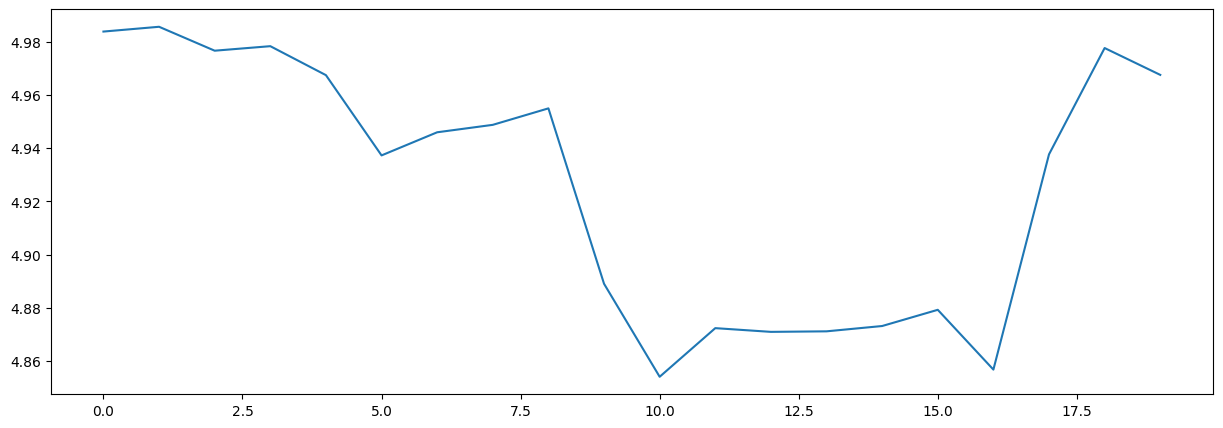

In [25]:
import matplotlib.pyplot as graf
graf.figure(figsize=(15,5))
graf.plot(lista3)